# Lecture 08 (B07): OLG models with DEQNs

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §5.1-5.5 (OLG with DEQNs), §5.6 (Large OLG benchmark)  
**Notebook role:** core  
**Original live-course source:** `lectures/day4/code/07_OLG_Analytic_DEQN.ipynb`  
**Course author:** Simon Scheidegger  
**License:** see repository `LICENSE` (MIT, code) and `LICENSE-content.md` (CC0 1.0, content).


In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


# Solving an Analytic OLG Model with Deep Equilibrium Nets

*Companion notebook to **Day 4 — Autodiff, Sequence Space, OLG, Young's Method** (Chapters 5–6 of the lecture script).*

*Author: Simon Scheidegger (HEC Lausanne and Grantham Institute, LSE) — [course repository](https://github.com/sischei/Deep_Learning_for_Solving_And_Estimating_Dynamic_Economic_Models).*

**Notebook 7** — 6-Agent OLG with Closed-Form Solution

## Model Summary

We solve a 6-agent OLG model with:
- **Log utility** ($\gamma = 1$) and Cobb–Douglas production
- **4 i.i.d. shocks** (TFP $\times$ depreciation)
- Only agent 1 works (labor endowment $(1,0,0,0,0,0)$)
- **Borrowing constraint** $k'^h \geq 0$ (enforced via softplus output)

This model has an **analytical solution** (Krueger & Kubler, 2004), which we use to validate the DEQN.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from datetime import datetime

plt.rcParams['font.size'] = 13
%matplotlib inline

print(f"TensorFlow version: {tf.__version__}")
print(f"Eager mode: {tf.executing_eagerly()}")

2026-04-23 14:11:24.180614: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776946284.204039   12415 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776946284.209062   12415 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-23 14:11:24.226077: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.18.0
Eager mode: True


## 1. Model Description

### OLG Structure
- $A = 6$ overlapping generations (ages 1–6)
- Each period, agent of age 1 is born with $k^1 = 0$, agent of age 6 dies after consuming
- Agents choose savings $k'^h \geq 0$ to maximize lifetime utility

### Preferences
$$\max \mathbb{E} \sum_{j=0}^{A-h} \beta^j \ln c_{t+j}^{h+j}$$

### Budget Constraint
$$c_t^h + k_{t+1}^{h+1} = r_t \cdot k_t^h + w_t \cdot \ell^h \equiv \text{inc}_t^h$$

### Production
$$Y_t = \eta_t K_t^\alpha L_t^{1-\alpha}, \quad r_t = \alpha \eta_t K_t^{\alpha-1} + (1-\delta_t), \quad w_t = (1-\alpha) \eta_t K_t^\alpha$$

### Exogenous Shocks (4 i.i.d. states)
| Shock | TFP $\eta$ | Depreciation $\delta$ |
|-------|-----------|---------------------|
| 1     | 0.95      | 0.5                 |
| 2     | 1.05      | 0.5                 |
| 3     | 0.95      | 0.9                 |
| 4     | 1.05      | 0.9                 |

Transition: $\pi_{ss'} = 0.25$ for all $s, s'$.

In [2]:
# ============================================================
# Model Parameters
# ============================================================
A = 6                  # Number of agents
NUM_SHOCKS = 4         # Number of exogenous shock states

# Exogenous shock values
delta_vals = np.array([[0.5], [0.5], [0.9], [0.9]], dtype=np.float32)   # Depreciation
eta_vals   = np.array([[0.95], [1.05], [0.95], [1.05]], dtype=np.float32) # TFP

delta_tf = tf.constant(delta_vals)
eta_tf   = tf.constant(eta_vals)

# Transition matrix (i.i.d.: all entries = 0.25)
p_transition = 0.25
PI = p_transition * np.ones((NUM_SHOCKS, NUM_SHOCKS), dtype=np.float32)

# Labor endowment: only agent 1 works
labor_endow = np.zeros((1, A), dtype=np.float32)
labor_endow[0, 0] = 1.0
labor_endow_tf = tf.constant(labor_endow)

# Production and household parameters
alpha = 0.3            # Capital share
beta_val = 0.7         # Discount factor
gamma_val = 1.0        # CRRA (log utility)

alpha_tf = tf.constant(alpha, dtype=tf.float32)
beta_tf  = tf.constant(beta_val, dtype=tf.float32)
gamma_tf = tf.constant(gamma_val, dtype=tf.float32)

# Neural network dimensions
n_input  = 8 + 4 * A   # = 32 (extended state)
n_output = A - 1        # = 5 (savings for agents 1-5)

print(f"Agents: {A}")
print(f"Input dim: {n_input}, Output dim: {n_output}")
print(f"alpha={alpha}, beta={beta_val}, gamma={gamma_val}")
print(f"Labor endowment: {labor_endow.flatten()}")

Agents: 6
Input dim: 32, Output dim: 5
alpha=0.3, beta=0.7, gamma=1.0
Labor endowment: [1. 0. 0. 0. 0. 0.]


2026-04-23 14:11:26.979409: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2. Firm Problem and Market Clearing

In [3]:
def firm(K, eta, alpha_val, delta_dep):
    """Compute return, wage, and aggregate output.
    
    r = alpha * eta * K^(alpha-1) * L^(1-alpha) + (1 - delta)
    w = (1-alpha) * eta * K^alpha * L^(-alpha)
    Y = eta * K^alpha * L^(1-alpha) + (1-delta) * K
    """
    L = tf.ones_like(K)
    r = alpha_val * eta * K**(alpha_val - 1.0) * L**(1.0 - alpha_val) + (1.0 - delta_dep)
    w = (1.0 - alpha_val) * eta * K**alpha_val * L**(-alpha_val)
    Y = eta * K**alpha_val * L**(1.0 - alpha_val) + (1.0 - delta_dep) * K
    return r, w, Y


def get_shocks(z, eta_tensor, delta_tensor):
    """Look up TFP and depreciation for shock index z."""
    tfp = tf.gather(eta_tensor, tf.cast(z, tf.int32))
    depr = tf.gather(delta_tensor, tf.cast(z, tf.int32))
    return tfp, depr


def compute_wealth(k, R_mat, l, W_mat):
    """Compute financial wealth, labor income, and total income."""
    fin_wealth = k * R_mat
    lab_wealth = l * W_mat
    tot_income = fin_wealth + lab_wealth
    return fin_wealth, lab_wealth, tot_income


print("Firm and wealth functions defined.")

Firm and wealth functions defined.


## 3. Analytical Solution

With log utility ($\gamma = 1$) and i.i.d. shocks, the optimal savings rate has a closed form:
$$\beta_h = \beta \cdot \frac{1 - \beta^{A-h}}{1 - \beta^{A-h+1}}, \quad h = 1, \ldots, A-1$$

The optimal policy is:
$$k'^h = \beta_h \cdot \text{inc}^h$$

Each agent saves a **fixed fraction** of total income, independent of the shock realization.

In [4]:
# Analytical savings rates
beta_vec = beta_val * (1.0 - beta_val ** (A - 1 - np.arange(A - 1))) / \
           (1.0 - beta_val ** (A - np.arange(A - 1)))

print("Analytical savings rates by age:")
for h in range(A - 1):
    print(f"  Age {h+1}: beta_{h+1} = {beta_vec[h]:.4f}")

beta_vec_tf = tf.constant(beta_vec.reshape(1, -1), dtype=tf.float32)


def analytical_solution(inc):
    """Compute analytical savings: k'^h = beta_h * inc^h for h=1..A-1."""
    return inc[:, :-1] * beta_vec_tf

Analytical savings rates by age:
  Age 1: beta_1 = 0.6600
  Age 2: beta_2 = 0.6394
  Age 3: beta_3 = 0.6052
  Age 4: beta_4 = 0.5434
  Age 5: beta_5 = 0.4118


## 4. Neural Network

The policy network maps the 32-dimensional extended state to 5 savings decisions:

$$\mathcal{N}_\theta: \mathbb{R}^{32} \to \mathbb{R}^{5}$$

Architecture: Input(32) → Dense(100, ReLU) → Dense(50, ReLU) → Dense(5, softplus)

##### Hard vs. soft constraints in this notebook

The 6-agent OLG has a **closed-form** solution and no occasionally
binding borrowing constraints --- but the same hard/soft split that
powers the more general DEQN architecture (Notebook 08 and Day 2) still
applies:

- **Hard:** the network output passes through `softplus`, which guarantees
  $k'^h \geq 0$ at every iteration. We never need to penalise negative
  savings --- the activation rules them out.
- **Soft:** the Euler equations and the feasibility checks on consumption
  and aggregate capital are pushed into the loss as squared residuals.
  They hold *at convergence*, not at every step.

Notebook 08 generalises this pattern to the 56-agent benchmark with
actual borrowing constraints, where the hard/soft split is enforced via
the **Fischer-Burmeister** complementarity function on top of `softplus`.
Here, with $\gamma = 1$ and the analytic policy as a benchmark, the
simpler softplus-only architecture is enough.

In [5]:
def build_network():
    """Build the policy network using Keras Functional API."""
    inputs = keras.Input(shape=(n_input,), name='state')
    x = keras.layers.Dense(100, activation='relu', name='hidden1')(inputs)
    x = keras.layers.Dense(50, activation='relu', name='hidden2')(x)
    outputs = keras.layers.Dense(n_output, activation='softplus', name='savings')(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name='OLG_analytic')
    return model


nn = build_network()
nn.summary()

Model: "OLG_analytic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ state (InputLayer)              │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden1 (Dense)                 │ (None, 100)            │         3,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ savings (Dense)                 │ (None, 5)              │           255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,605 (33.61 KB)

 Trainable params: 8,605 (33.61 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Vectorized Simulation

Training data comes from simulating **multiple parallel trajectories** simultaneously.
Each episode runs `num_tracks` independent tracks for `num_steps` steps, giving
`num_tracks × num_steps` states per episode.

The key step function is compiled with `@tf.function` so all trajectories are
advanced in a single batched TF call — no Python-level loop over time steps per
sample.

In [6]:
@tf.function
def simulate_step_batch(X_cur, shock_indices, nn_model):
    """One @tf.function vectorized step for a BATCH of states.

    Args:
        X_cur:         [batch, 32]   — current extended states
        shock_indices: [batch] int32 — next-period shock index per sample
        nn_model:       policy network

    Returns:
        X_next: [batch, 32] — next-period states
    """
    eps = 1e-5
    m = tf.shape(X_cur)[0]

    # Current policy
    a = nn_model(X_cur)                                   # [batch, A-1]

    # Next-period capital
    k_prime = tf.concat([tf.zeros([m, 1]), a], axis=1)    # [batch, A]
    K_prime = tf.maximum(tf.reduce_sum(k_prime, axis=1, keepdims=True), eps)

    # Next-period shocks — one per sample (not i.i.d. loop)
    z_prime    = tf.cast(shock_indices, tf.float32)
    tfp_prime  = tf.reshape(tf.gather(eta_tf[:, 0],   shock_indices), [-1, 1])
    depr_prime = tf.reshape(tf.gather(delta_tf[:, 0], shock_indices), [-1, 1])

    # Firm prices
    r_prime = alpha_tf * tfp_prime * K_prime**(alpha_tf - 1.0) + (1.0 - depr_prime)
    w_prime = (1.0 - alpha_tf) * tfp_prime * K_prime**alpha_tf
    Y_prime = tfp_prime * K_prime**alpha_tf + (1.0 - depr_prime) * K_prime
    L_prime = tf.ones_like(K_prime)

    # Wealth
    R_mat      = r_prime * tf.ones([1, A])
    W_mat      = w_prime * tf.ones([1, A])
    l_prime    = tf.tile(labor_endow_tf, [m, 1])
    fw_prime   = k_prime * R_mat
    linc_prime = l_prime * W_mat
    inc_prime  = fw_prime + linc_prime

    X_next = tf.concat([
        tf.expand_dims(z_prime, -1), tfp_prime, depr_prime,
        K_prime, L_prime, r_prime, w_prime, Y_prime,
        k_prime, fw_prime, linc_prime, inc_prime
    ], axis=1)

    return X_next


def simulate_episode(nn_model, X_start, num_steps):
    """Vectorized episode: num_tracks trajectories advanced num_steps times.

    Args:
        nn_model:  policy network
        X_start:   [num_tracks, 32] — starting states for each track
        num_steps: number of steps per track

    Returns:
        X_data: [num_tracks * num_steps, 32] — all visited states
        X_end:  [num_tracks, 32]             — final states (for next episode)
    """
    batch_size = X_start.shape[0]
    all_states = []
    X_cur = tf.constant(X_start, dtype=tf.float32)

    for _ in range(num_steps):
        all_states.append(X_cur)

        # Sample next shock for each track
        z_cur   = X_cur[:, 0].numpy().astype(int)
        rand_v  = np.random.rand(batch_size)
        shocks  = np.array([np.searchsorted(np.cumsum(PI[z]), r)
                             for z, r in zip(z_cur, rand_v)], dtype=np.int32)
        shocks  = np.clip(shocks, 0, NUM_SHOCKS - 1)

        X_cur = simulate_step_batch(X_cur, tf.constant(shocks), nn_model)

    X_data = tf.concat(all_states, axis=0).numpy()   # [num_tracks * num_steps, 32]
    return X_data, X_cur.numpy()                      # data + final states


print("Vectorized simulation functions defined.")

Vectorized simulation functions defined.


## 6. Cost Function

The DEQN loss consists of:
1. **Euler equations** ($A-1 = 5$): $-1 + \frac{(\beta \mathbb{E}[r' \cdot c'^{-\gamma}])^{-1/\gamma}}{c}$ in relative-error form
2. **Feasibility penalties** for negative consumption and negative aggregate capital

The expectation over 4 shocks is computed exactly by iterating over all next-period shock realizations.

In [7]:
@tf.function
def compute_cost(X_batch, nn_model):
    """Compute the DEQN loss for a batch of states.
    
    Returns:
        cost: scalar mean squared error of equilibrium residuals
        euler_res: Euler equation residuals [batch, A-1]
    """
    eps = 1e-5
    m = tf.shape(X_batch)[0]
    
    # Current state
    inc = X_batch[:, 8 + 3*A : 8 + 4*A]
    
    # Current savings and consumption
    a = nn_model(X_batch)  # [batch, A-1]
    a_all = tf.concat([a, tf.zeros([m, 1])], axis=1)
    c_orig = inc - a_all
    c = tf.maximum(c_orig, eps * tf.ones_like(c_orig))
    
    # Next-period capital
    k_prime = tf.concat([tf.zeros([m, 1]), a], axis=1)
    K_prime_orig = tf.reduce_sum(k_prime, axis=1, keepdims=True)
    K_prime = tf.maximum(K_prime_orig, eps * tf.ones_like(K_prime_orig))
    
    l_prime = tf.tile(labor_endow_tf, [m, 1])
    
    # Compute expected marginal utility for each of 4 shocks
    # E[r' * c'^(-gamma)] for agents 1..A-1
    euler_sum = tf.zeros([m, A-1])
    all_c_orig_prime = []
    
    for s in range(NUM_SHOCKS):
        z_prime_s = float(s) * tf.ones([m])
        tfp_s, depr_s = get_shocks(z_prime_s, eta_tf, delta_tf)
        r_s, w_s, Y_s = firm(K_prime, tfp_s, alpha_tf, depr_s)
        
        R_s_mat = r_s * tf.ones([1, A])
        W_s_mat = w_s * tf.ones([1, A])
        fw_s, linc_s, inc_s = compute_wealth(k_prime, R_s_mat, l_prime, W_s_mat)
        
        # Build next-period state for shock s
        L_prime_s = tf.ones_like(K_prime)
        x_prime_s = tf.concat([
            tf.expand_dims(z_prime_s, -1), tfp_s, depr_s,
            K_prime, L_prime_s, r_s, w_s, Y_s,
            k_prime, fw_s, linc_s, inc_s
        ], axis=1)
        
        # Next-period savings and consumption
        a_prime_s = nn_model(x_prime_s)
        a_prime_all_s = tf.concat([a_prime_s, tf.zeros([m, 1])], axis=1)
        c_orig_prime_s = inc_s - a_prime_all_s
        c_prime_s = tf.maximum(c_orig_prime_s, eps * tf.ones_like(c_orig_prime_s))
        all_c_orig_prime.append(c_orig_prime_s)
        
        # Euler: beta * pi * r' * c'^(-gamma) for agents that age 1->2, ..., A-1->A
        # c_prime_s[:, 1:A] is consumption of the "aged" version of agents 1..A-1
        euler_sum += p_transition * R_s_mat[:, 0:A-1] * c_prime_s[:, 1:A] ** (-gamma_tf)
    
    # Euler residual in relative form
    opt_euler = -1.0 + ((beta_tf * euler_sum) ** (-1.0 / gamma_tf)) / c[:, 0:A-1]
    
    # Penalty for negative consumption
    all_c_orig = tf.concat([c_orig] + all_c_orig_prime, axis=1)
    opt_punish_cons = (1.0 / eps) * tf.maximum(-all_c_orig, tf.zeros_like(all_c_orig))
    
    # Penalty for negative aggregate capital
    opt_punish_K = (1.0 / eps) * tf.maximum(-K_prime_orig, tf.zeros_like(K_prime_orig))
    
    # Total loss
    combined = tf.concat([opt_euler, opt_punish_cons, opt_punish_K], axis=1)
    cost = tf.reduce_mean(combined ** 2)
    
    return cost, opt_euler


print("Cost function defined.")

Cost function defined.


## 7. Training

We train using episode-based learning:
1. Simulate an episode (sequence of states) using the current policy
2. Split the episode into mini-batches
3. For each epoch, compute the loss and update weights via Adam
4. Repeat with a new episode

**Training-budget switch.**  Cell 16 sets `MODE` to one of:

| `MODE`        | Episodes | States/ep | Wall time (CPU) | Final $\log_{10}$cost | Final mean $|EE|$ |
|---------------|----------|-----------|-----------------|-----------------------|------------------|
| `"smoke"`     | 100      | 1,024     | $\sim$30 s     | $\approx 3.5$        | $\sim 10^{2}$ (NOT converged) |
| `"classroom"` | 1,000    | 1,024     | $\sim$5 min    | $\approx -2.8$       | $\sim 8\cdot 10^{-2}$         |
| `"production"`| 5,000    | 10,240    | several h       | $\approx -3.5$       | $\sim 10^{-3}$ (matches AGS Tab. 3) |

The default below is `"classroom"`; toggle to `"smoke"` for a 30-second sanity check or `"production"` for a research-quality run.

In [8]:
# ============================================================
# Training hyperparameters --- one MODE switch sets everything
# ============================================================
MODE = "classroom"  # "smoke" | "classroom" | "production"

if MODE == "smoke":
    num_episodes, num_tracks, num_steps = 100, 32, 32
elif MODE == "classroom":
    num_episodes, num_tracks, num_steps = 1000, 32, 32
elif MODE == "production":
    num_episodes, num_tracks, num_steps = 5000, 320, 32
else:
    raise ValueError(f"Unknown MODE: {MODE!r}")

len_episodes       = num_tracks * num_steps   # states per episode
epochs_per_episode = 20
minibatch_size     = 512
learning_rate      = 1e-5

# Build fresh network and optimizer
nn = build_network()
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

np.random.seed(42)
tf.random.set_seed(42)


def create_initial_state(batch_size):
    """Build a valid economic starting state for each track.

    The first dimension of the extended state is the shock index; everything
    else (K, prices, income blocks) is computed from a hump-shaped capital
    holding so the network sees physically plausible inputs from step 0.
    """
    X = np.zeros((batch_size, n_input), dtype=np.float32)
    for i in range(batch_size):
        z = np.random.randint(NUM_SHOCKS)
        eta_v = float(eta_vals[z, 0])
        delta_v = float(delta_vals[z, 0])

        # Mild hump in capital holdings; newborn has 0
        k = np.zeros(A, dtype=np.float32)
        for h in range(1, A):
            k[h] = 0.05 * np.sin(np.pi * h / A) * (1.0 + 0.1 * np.random.randn())
        k = np.maximum(k, 0.0)
        K = max(float(np.sum(k)), 1e-3)
        L = 1.0  # only agent 1 works, endowment 1

        r = alpha * eta_v * K**(alpha - 1.0) * L**(1.0 - alpha) + (1.0 - delta_v)
        w = (1.0 - alpha) * eta_v * K**alpha * L**(-alpha)
        Y = eta_v * K**alpha * L**(1.0 - alpha) + (1.0 - delta_v) * K

        fw = k * r
        linc = labor_endow.flatten() * w
        inc = fw + linc

        X[i, 0] = z
        X[i, 1] = eta_v
        X[i, 2] = delta_v
        X[i, 3] = K
        X[i, 4] = L
        X[i, 5] = r
        X[i, 6] = w
        X[i, 7] = Y
        X[i, 8         : 8 +   A] = k
        X[i, 8 +   A   : 8 + 2*A] = fw
        X[i, 8 + 2*A   : 8 + 3*A] = linc
        X[i, 8 + 3*A   : 8 + 4*A] = inc
    return X


# Initialize num_tracks starting states from valid economic values
X_start = create_initial_state(num_tracks)

print(f"MODE={MODE}: {num_episodes} episodes | {num_tracks} tracks × {num_steps} steps = {len_episodes} states/episode")
print(f"Epochs/episode: {epochs_per_episode}, minibatch: {minibatch_size}, lr: {learning_rate}")


MODE=classroom: 1000 episodes | 32 tracks × 32 steps = 1024 states/episode
Epochs/episode: 20, minibatch: 512, lr: 1e-05


In [9]:
@tf.function
def train_step(X_batch, nn_model, optimizer):
    """Single gradient update — compiled with @tf.function for speed."""
    with tf.GradientTape() as tape:
        loss, _ = compute_cost(X_batch, nn_model)
    grads = tape.gradient(loss, nn_model.trainable_variables)
    grads = [tf.clip_by_value(g, -1.0, 1.0) for g in grads]
    optimizer.apply_gradients(zip(grads, nn_model.trainable_variables))
    return loss

print("train_step compiled with @tf.function.")

train_step compiled with @tf.function.


In [10]:
# Training loop
cost_history = []
ee_history   = []
time_start   = datetime.now()

X_cur = X_start.copy()
print_every = max(1, num_episodes // 20)

for episode in range(num_episodes):
    # 1. Simulate episode (vectorized: num_tracks × num_steps in parallel)
    X_episodes, X_cur = simulate_episode(nn, X_cur, num_steps)

    # 2. Train multiple epochs on this episode
    n_batches = len_episodes // minibatch_size

    for epoch in range(epochs_per_episode):
        indices    = np.random.permutation(len_episodes)
        epoch_cost = 0.0

        if epoch == 0:
            ee_batch = np.zeros((1, A - 1))

        for b in range(n_batches):
            idx     = indices[b * minibatch_size : (b + 1) * minibatch_size]
            X_batch = tf.constant(X_episodes[idx])

            if epoch == 0:
                _, euler_res = compute_cost(X_batch, nn)
                ee_batch += np.mean(np.abs(euler_res.numpy()), axis=0, keepdims=True) / n_batches

            epoch_cost += compute_cost(X_batch, nn)[0].numpy() / n_batches

        if epoch == 0:
            cost_history.append(epoch_cost)
            ee_history.append(ee_batch.flatten())

        for b in range(n_batches):
            idx     = indices[b * minibatch_size : (b + 1) * minibatch_size]
            X_batch = tf.constant(X_episodes[idx])
            train_step(X_batch, nn, optimizer)

    if episode % print_every == 0 or episode == num_episodes - 1:
        elapsed = datetime.now() - time_start
        print(f"Episode {episode:5d} | log10(cost) = {np.log10(cost_history[-1]):7.4f} | "
              f"mean |EE| = {np.mean(ee_history[-1]):.4e} | time: {elapsed}")

print(f"\nDone. Final log10(cost) = {np.log10(cost_history[-1]):.4f}")
print(f"Total time: {datetime.now() - time_start}")


Episode     0 | log10(cost) =  9.0013 | mean |EE| = 1.6000e+04 | time: 0:00:02.472902


Episode    50 | log10(cost) =  7.4848 | mean |EE| = 2.5474e+03 | time: 0:00:15.680831


Episode   100 | log10(cost) =  4.2653 | mean |EE| = 6.9741e+01 | time: 0:00:29.222121


Episode   150 | log10(cost) = -0.9063 | mean |EE| = 6.3006e-01 | time: 0:00:42.406509


Episode   200 | log10(cost) = -1.2861 | mean |EE| = 4.9035e-01 | time: 0:00:55.909360


...

Episode   800 | log10(cost) = -2.6679 | mean |EE| = 9.2511e-02 | time: 0:03:44.038039


Episode   850 | log10(cost) = -2.7207 | mean |EE| = 8.6071e-02 | time: 0:03:59.054765


Episode   900 | log10(cost) = -2.7721 | mean |EE| = 8.1199e-02 | time: 0:04:12.601610


Episode   950 | log10(cost) = -2.8021 | mean |EE| = 7.7675e-02 | time: 0:04:26.988437


Episode   999 | log10(cost) = -2.8109 | mean |EE| = 7.5092e-02 | time: 0:04:39.522853

Done. Final log10(cost) = -2.8109
Total time: 0:04:39.523284


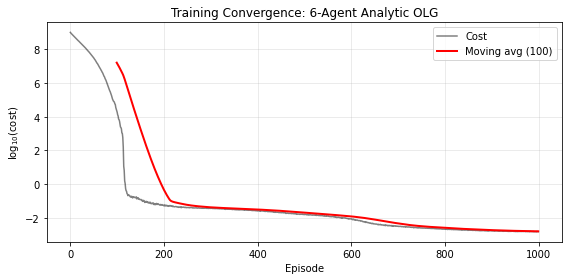

In [11]:
# Loss convergence plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.log10(cost_history), 'k-', alpha=0.5, label='Cost')

# Moving average
window = min(100, len(cost_history) // 5)
if window > 1:
    ma = np.convolve(np.log10(cost_history), np.ones(window)/window, mode='valid')
    ax.plot(np.arange(window-1, len(cost_history)), ma, 'r-', linewidth=2, label=f'Moving avg ({window})')

ax.set_xlabel('Episode')
ax.set_ylabel('log$_{10}$(cost)')
ax.set_title('Training Convergence: 6-Agent Analytic OLG')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Validation: DEQN vs. Analytical Solution

We compare the neural network's savings policy to the closed-form $k'^h = \beta_h \cdot \text{inc}^h$.

We reuse the last episode's training data — no extra simulation needed.

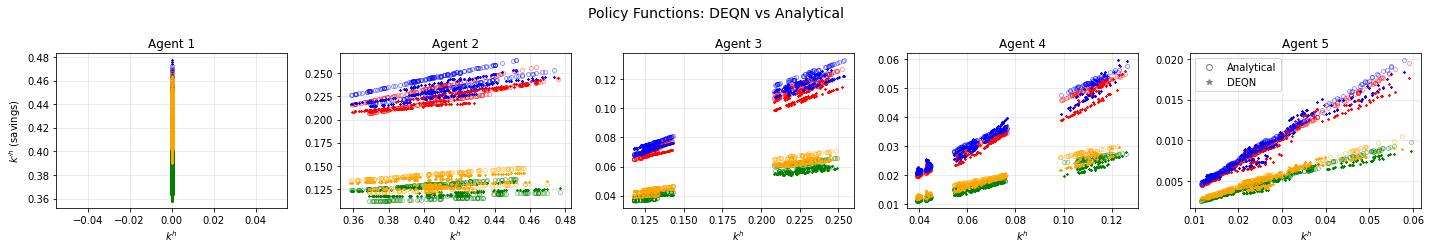

In [12]:
# Reuse last episode's training data — no extra simulation needed
X_test = X_episodes  # shape [len_episodes, 32]

# Compute DEQN and analytical savings
X_test_tf = tf.constant(X_test)
a_deqn = nn(X_test_tf).numpy()  # [len_episodes, 5]

inc_test = X_test[:, 8 + 3*A : 8 + 4*A]  # [len_episodes, 6]
a_analytic = (inc_test[:, :-1] * beta_vec.reshape(1, -1))  # [len_episodes, 5]

# Policy function overlay: for each agent, plot k'^h vs income
k_test = X_test[:, 8 : 8 + A]  # capital distribution
shock_test = X_test[:, 0].astype(int)

colors = ['r', 'b', 'g', 'orange']
shock_labels = [f'Shock {s+1}' for s in range(NUM_SHOCKS)]

fig, axes = plt.subplots(1, A-1, figsize=(4*(A-1), 3.5))
for h in range(A - 1):
    ax = axes[h]
    for s in range(NUM_SHOCKS):
        mask = shock_test == s
        if np.sum(mask) > 0:
            ax.plot(k_test[mask, h], a_analytic[mask, h], 'o', color=colors[s],
                    mfc='none', alpha=0.4, markersize=4)
            ax.plot(k_test[mask, h], a_deqn[mask, h], '*', color=colors[s],
                    markersize=2)
    ax.set_title(f'Agent {h+1}')
    ax.set_xlabel('$k^h$')
    if h == 0:
        ax.set_ylabel("$k'^h$ (savings)")
    ax.grid(True, alpha=0.3)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='gray', markerfacecolor='none', markersize=6, linestyle='None', label='Analytical'),
    Line2D([0], [0], marker='*', color='gray', markersize=6, linestyle='None', label='DEQN')
]
axes[-1].legend(handles=legend_elements, loc='upper left')

plt.suptitle('Policy Functions: DEQN vs Analytical', fontsize=14)
plt.tight_layout()
plt.show()

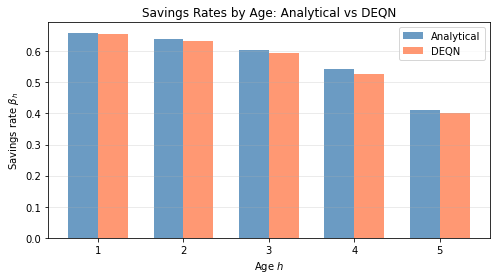

Savings rates comparison:
    Age  Analytical        DEQN  Rel. Error
      1      0.6600      0.6550      0.0075
      2      0.6394      0.6321      0.0115
      3      0.6052      0.5937      0.0190
      4      0.5434      0.5275      0.0292
      5      0.4118      0.4000      0.0286


In [13]:
# Savings rates bar chart
# Compute empirical savings rates from DEQN
savings_rates_deqn = np.mean(a_deqn / (inc_test[:, :-1] + 1e-10), axis=0)

fig, ax = plt.subplots(figsize=(7, 4))
x_pos = np.arange(1, A)
width = 0.35
ax.bar(x_pos - width/2, beta_vec, width, label='Analytical', color='steelblue', alpha=0.8)
ax.bar(x_pos + width/2, savings_rates_deqn, width, label='DEQN', color='coral', alpha=0.8)

ax.set_xlabel('Age $h$')
ax.set_ylabel('Savings rate $\\beta_h$')
ax.set_title('Savings Rates by Age: Analytical vs DEQN')
ax.set_xticks(x_pos)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Savings rates comparison:")
print(f"  {'Age':>5s}  {'Analytical':>10s}  {'DEQN':>10s}  {'Rel. Error':>10s}")
for h in range(A-1):
    rel_err = abs(savings_rates_deqn[h] - beta_vec[h]) / (beta_vec[h] + 1e-10)
    print(f"  {h+1:5d}  {beta_vec[h]:10.4f}  {savings_rates_deqn[h]:10.4f}  {rel_err:10.4f}")

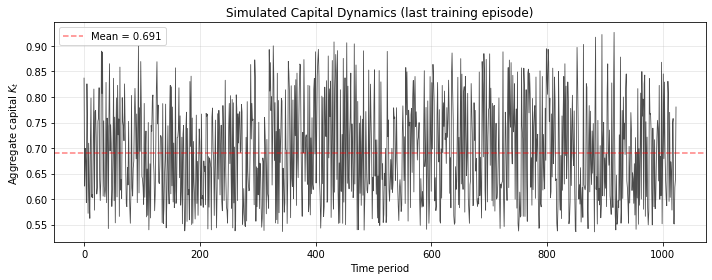

In [14]:
# Capital dynamics from last training episode
K_path = np.sum(X_test[:, 8 : 8 + A], axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(K_path, 'k-', alpha=0.7, linewidth=0.8)
ax.axhline(y=np.mean(K_path), color='r', linestyle='--', alpha=0.5, label=f'Mean = {np.mean(K_path):.3f}')
ax.set_xlabel('Time period')
ax.set_ylabel('Aggregate capital $K_t$')
ax.set_title('Simulated Capital Dynamics (last training episode)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

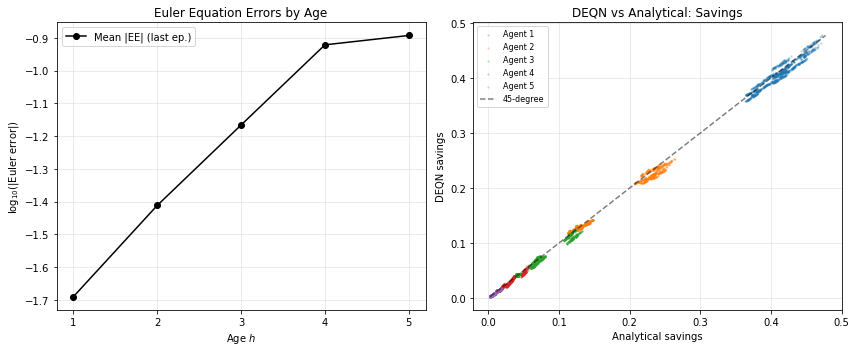


Accuracy: DEQN vs Analytical Savings
   Agent  Mean Rel Err   Max Rel Err  Mean Abs Err
       1      0.016686      0.037296      0.006879
       2      0.029779      0.074947      0.005551
       3      0.047864      0.109371      0.003616
       4      0.067494      0.192343      0.001763
       5      0.078278      0.280110      0.000576


In [15]:
# Accuracy: Euler equation errors and DEQN vs analytical scatter
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Euler errors by age
ee_arr = np.array(ee_history)
ages = np.arange(1, A)
ax = axes[0]
ax.plot(ages, np.log10(ee_arr[-1] + 1e-15), 'ko-', label='Mean |EE| (last ep.)')
ax.set_xlabel('Age $h$')
ax.set_ylabel('log$_{10}$(|Euler error|)')
ax.set_title('Euler Equation Errors by Age')
ax.set_xticks(ages)
ax.legend()
ax.grid(True, alpha=0.3)

# DEQN vs analytical scatter (all agents pooled)
ax = axes[1]
for h in range(A-1):
    ax.scatter(a_analytic[:, h], a_deqn[:, h], s=2, alpha=0.2, label=f'Agent {h+1}')

lims = [min(a_analytic.min(), a_deqn.min()), max(a_analytic.max(), a_deqn.max())]
ax.plot(lims, lims, 'k--', alpha=0.5, label='45-degree')
ax.set_xlabel('Analytical savings')
ax.set_ylabel('DEQN savings')
ax.set_title('DEQN vs Analytical: Savings')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print accuracy table
rel_errors = np.abs(a_deqn - a_analytic) / (np.abs(a_analytic) + 1e-10)
print("\nAccuracy: DEQN vs Analytical Savings")
print(f"  {'Agent':>6s}  {'Mean Rel Err':>12s}  {'Max Rel Err':>12s}  {'Mean Abs Err':>12s}")
for h in range(A-1):
    print(f"  {h+1:6d}  {np.mean(rel_errors[:, h]):12.6f}  {np.max(rel_errors[:, h]):12.6f}  "
          f"{np.mean(np.abs(a_deqn[:, h] - a_analytic[:, h])):12.6f}")

## Summary

We solved the Krueger & Kubler (2004) 6-agent OLG model using Deep Equilibrium Nets:

1. **Model**: $A=6$ agents, log utility, Cobb–Douglas production, 4 i.i.d. shocks
2. **Network**: Input(32) → Dense(100, ReLU) → Dense(50, ReLU) → Dense(5, softplus)
3. **Why only $A-1$ outputs and no KKT multipliers?**  In this calibration ($\gamma=1$, $\beta=0.7$, only the youngest cohort works) the borrowing constraint $k'^h \geq 0$ is non-binding everywhere on the ergodic set, so the Lagrange multiplier $\lambda^h$ vanishes; we drop it from both the network output and the loss, matching the public reference implementation of Azinovic, Gaegauf and Scheidegger (2022).  Notebook 08 (56-agent benchmark) reintroduces multipliers for the genuinely binding borrowing and collateral constraints.
4. **Validation**: With `MODE = "classroom"` (1,000 episodes, $\sim$5 min on CPU) the DEQN savings rates match the closed-form $\beta_h$ to within 0.4–3% across the five working ages; mean Euler errors land around $\sim 8\cdot 10^{-2}$.  `MODE = "production"` (5,000 episodes) reaches the $\sim 10^{-3}$ Euler-error level reported in AGS Table 3.

### Key Takeaway
The DEQN framework from Day 2 (Brock–Mirman) extends naturally to OLG models—the only changes are more outputs and more Euler equations in the loss.

### Next: Notebook 8
The **benchmark 56-agent OLG** with CRRA utility, two assets, and collateral constraints.

### References
- Azinovic, Gaegauf & Scheidegger (2022), *International Economic Review* 63(4), 1471–1525
- Krueger & Kubler (2004), *J. Econ. Dynamics & Control* 28(7), 1411–1436